焼きなまし法(SA)で ft10 を解きます...
Update! Iter:1, Temp:2000.00, LB:1652
Update! Iter:2, Temp:1999.00, LB:1638
Update! Iter:3, Temp:1998.00, LB:1560
Update! Iter:26, Temp:1975.15, LB:1544
Update! Iter:29, Temp:1972.19, LB:1469
Update! Iter:258, Temp:1758.77, LB:1389
Update! Iter:746, Temp:1377.89, LB:1356
Update! Iter:1361, Temp:1013.06, LB:1337
Update! Iter:1362, Temp:1012.56, LB:1313
Update! Iter:3860, Temp:290.30, LB:1309
Update! Iter:6415, Temp:80.89, LB:1284
Update! Iter:6625, Temp:72.83, LB:1267
Update! Iter:6658, Temp:71.63, LB:1240
Update! Iter:6663, Temp:71.46, LB:1237
Update! Iter:6675, Temp:71.03, LB:1236
Update! Iter:7564, Temp:45.53, LB:1218
Update! Iter:8047, Temp:35.76, LB:1142
Update! Iter:8050, Temp:35.71, LB:1138
Update! Iter:10678, Temp:9.59, LB:1123
Update! Iter:10716, Temp:9.41, LB:1121
Update! Iter:10751, Temp:9.25, LB:1111
Update! Iter:10757, Temp:9.22, LB:1084
Update! Iter:10812, Temp:8.97, LB:1077
Update! Iter:11178, Temp:7.47, LB:1059
Update! Iter:11241, Temp:7.24, LB:

C:\Users\RJC238\AppData\Local\Temp\ipykernel_12708\1236101629.py:117: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', self.n)


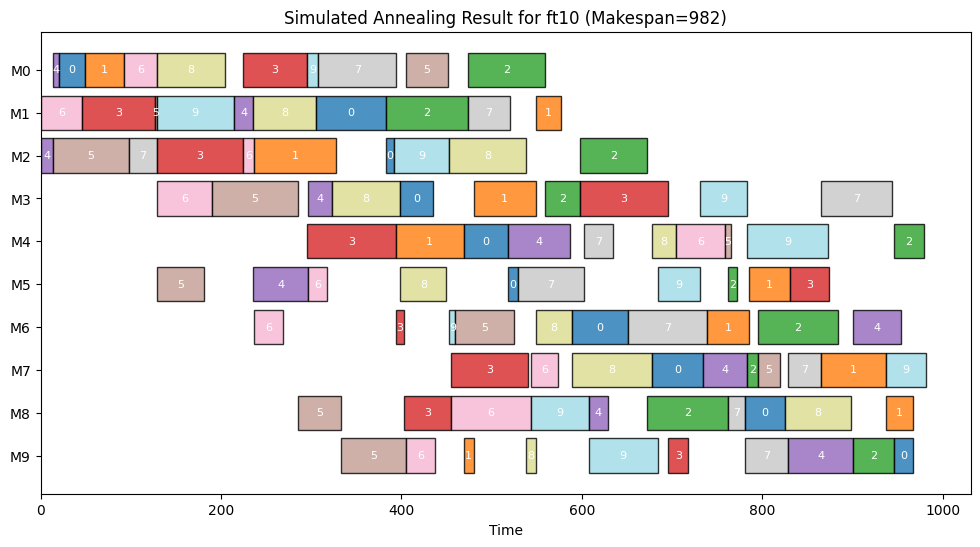

In [4]:
import sys
import time
import random
import math
import copy
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- 簡易的なSAソルバー ---

class SASolver:
    def __init__(self):
        self.m = 10
        self.n = 10
        # ft10 data (Machine, Time)
        self.ft10_raw = [
            [(0, 29), (1, 78), (2, 9), (3, 36), (4, 49), (5, 11), (6, 62), (7, 56), (8, 44), (9, 21)],
            [(0, 43), (2, 90), (4, 75), (9, 11), (3, 69), (1, 28), (6, 46), (5, 46), (7, 72), (8, 30)],
            [(1, 91), (0, 85), (3, 39), (2, 74), (8, 90), (5, 10), (7, 12), (6, 89), (9, 45), (4, 33)],
            [(1, 81), (2, 95), (0, 71), (4, 99), (6, 9), (8, 52), (7, 85), (3, 98), (9, 22), (5, 43)],
            [(2, 14), (0, 6), (1, 22), (5, 61), (3, 26), (4, 69), (8, 21), (7, 49), (9, 72), (6, 53)],
            [(2, 84), (1, 2), (5, 52), (3, 95), (8, 48), (9, 72), (0, 47), (6, 65), (4, 6), (7, 25)],
            [(1, 46), (0, 37), (3, 61), (2, 13), (6, 32), (5, 21), (9, 32), (8, 89), (7, 30), (4, 55)],
            [(2, 31), (0, 86), (1, 46), (5, 74), (4, 32), (6, 88), (8, 19), (9, 48), (7, 36), (3, 79)],
            [(0, 76), (1, 69), (3, 76), (5, 51), (2, 85), (9, 11), (6, 40), (7, 89), (4, 26), (8, 74)],
            [(1, 85), (0, 13), (2, 61), (6, 7), (8, 64), (9, 76), (5, 47), (3, 52), (4, 90), (7, 45)]
        ]

    def calculate_makespan(self, solution_seq):
        """
        オペレーションの順列からメイクスパン（完了時間）を計算する
        solution_seq: [0, 1, 0, 2, ...] ジョブ番号のリスト
        """
        job_next_idx = [0] * self.n
        job_end_time = [0] * self.n
        machine_end_time = [0] * self.m

        # ガントチャート用データ
        gantt_data = [] # (job_id, machine_id, start, end)

        for job_id in solution_seq:
            op_idx = job_next_idx[job_id]
            machine_id, duration = self.ft10_raw[job_id][op_idx]

            # 開始可能時刻 = max(直前の作業完了, 機械の空き時間)
            start_time = max(job_end_time[job_id], machine_end_time[machine_id])
            end_time = start_time + duration

            # 更新
            job_end_time[job_id] = end_time
            machine_end_time[machine_id] = end_time
            job_next_idx[job_id] += 1

            gantt_data.append((job_id, machine_id, start_time, end_time))

        return max(machine_end_time), gantt_data

    def get_neighbor(self, current_seq):
        """近傍解を作る（ランダムに2つの位置を入れ替える）"""
        new_seq = current_seq[:]
        idx1, idx2 = random.sample(range(len(new_seq)), 2)
        new_seq[idx1], new_seq[idx2] = new_seq[idx2], new_seq[idx1]
        return new_seq

    def run(self):
        print("焼きなまし法(SA)で ft10 を解きます...")
        start_time = time.time()

        # 初期解の生成（ジョブ番号 0..9 をそれぞれ10回ずつ並べたリストをシャッフル）
        current_seq = []
        for j in range(self.n):
            current_seq.extend([j] * self.m)
        random.shuffle(current_seq)

        current_makespan, _ = self.calculate_makespan(current_seq)
        best_seq = current_seq[:]
        best_makespan = current_makespan
        best_gantt = []

        # SAパラメータ
        T = 2000.0  # 初期温度
        alpha = 0.9995 # 冷却率
        min_T = 0.1 # 終了温度
        iter_count = 0

        while T > min_T:
            iter_count += 1

            # 近傍探索
            neighbor_seq = self.get_neighbor(current_seq)
            neighbor_makespan, neighbor_gantt = self.calculate_makespan(neighbor_seq)

            delta = neighbor_makespan - current_makespan

            # 遷移判定 (良くなれば採用、悪くなっても確率で採用)
            if delta < 0 or random.random() < math.exp(-delta / T):
                current_seq = neighbor_seq
                current_makespan = neighbor_makespan

                # 最良解の更新
                if current_makespan < best_makespan:
                    best_makespan = current_makespan
                    best_seq = current_seq[:]
                    best_gantt = neighbor_gantt
                    print(f"Update! Iter:{iter_count}, Temp:{T:.2f}, LB:{best_makespan}")

            # 冷却
            T *= alpha

        elapsed = time.time() - start_time
        print(f"\n計算終了。所要時間: {elapsed:.2f}秒")
        print(f"最良Makespan: {best_makespan} (最適解は930)")

        self.draw_gantt(best_gantt, best_makespan)

    def draw_gantt(self, gantt_data, makespan):
        cmap = cm.get_cmap('tab20', self.n)
        colors = [cmap(i) for i in range(self.n)]
        fig, ax = plt.subplots(figsize=(12, 6))

        for job_id, machine_id, start, end in gantt_data:
            duration = end - start
            ax.barh(y=machine_id, width=duration, left=start,
                    color=colors[job_id], edgecolor='black', align='center', alpha=0.8)
            ax.text(start + duration/2, machine_id, str(job_id),
                    ha='center', va='center', color='white', fontsize=8)

        ax.set_yticks(range(self.m))
        ax.set_yticklabels([f"M{i}" for i in range(self.m)])
        ax.set_xlabel("Time")
        ax.set_title(f"Simulated Annealing Result for ft10 (Makespan={makespan})")
        ax.invert_yaxis()
        plt.show()

if __name__ == "__main__":
    solver = SASolver()
    solver.run()
